# Interactive DRESS Demo
Welcome to the interactive demonstration of **DRESS**.

In this notebook, we'll install `dress-graph`, compute the DRESS edge representations for a classic network (the Karate Club graph), and visualize the resulting structural edge roles. 

> **Note:** DRESS computes values bounded strictly in `[0, 2]`. It is entirely parameter-free and discovers structural communities automatically.

In [1]:
# Install the DRESS python wrapper and visualization tools
!pip install -q dress-graph networkx matplotlib

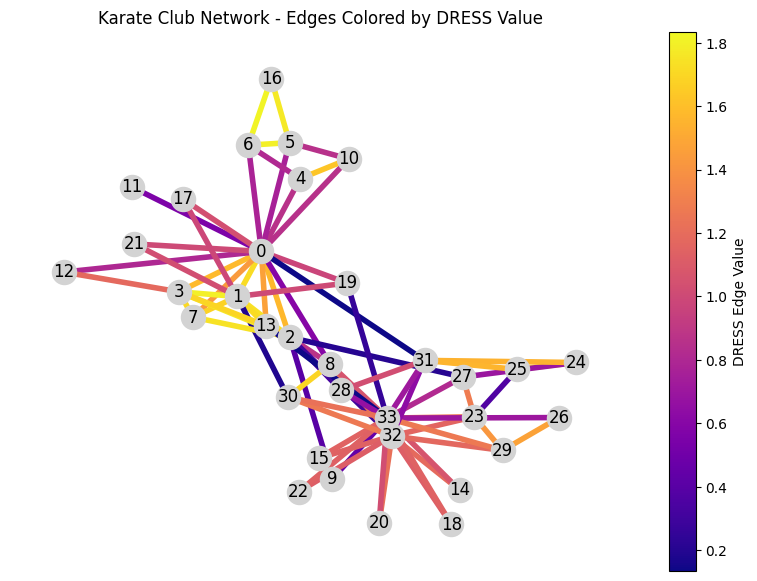

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from dress.networkx import fit

# 1. Load the Zachary Karate Club Graph
G = nx.karate_club_graph()

# 2. Compute DRESS values and magically assign them right back into NetworkX!
# Setting set_attributes=True attaches 'dress' to edges and 'vertex_dress' to nodes.
fit(G, set_attributes=True)

# 3. Extract the computed values for plotting
edge_values = [G[u][v]['dress'] for u, v in G.edges()]

# 4. Plot the graph! 
# Lighter/yellow colors are tightly knit structural edges (high DRESS)
# Darker/purple colors act as bridges between communities (low DRESS)
pos = nx.spring_layout(G, seed=42) # Fixed seed for reproducible layout
fig, ax = plt.subplots(figsize=(10, 7))

nx.draw(
    G, pos,
    ax=ax,
    node_color='lightgray',
    node_size=300,
    edge_color=edge_values,
    width=4.0,
    edge_cmap=plt.cm.plasma,
    with_labels=True
)

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(edge_values), vmax=max(edge_values)))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='DRESS Edge Value')
ax.set_title('Karate Club Network - Edges Colored by DRESS Value')
plt.show()

### What does this show?
Look at the colors of your edges! Notice how the edges that connect the main sub-components of the graph (bridges) score much lower (dark purple) than the core, dense triangles within the groups (bright yellow). 

No heuristics, no continuous hyperparameter tuning mapping, just a clean mathematical fixed point mapping discrete structure to a continuous domain.